In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
df = pd.read_csv("/content/15-gym_crowdedness.csv")

In [6]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [7]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [9]:
df.shape

(62184, 11)

In [10]:
sns.set_theme(style="whitegrid")

df["date"] = pd.to_datetime(df["date"])

/tmp/ipykernel_4581/3710608720.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["date"] = pd.to_datetime(df["date"])


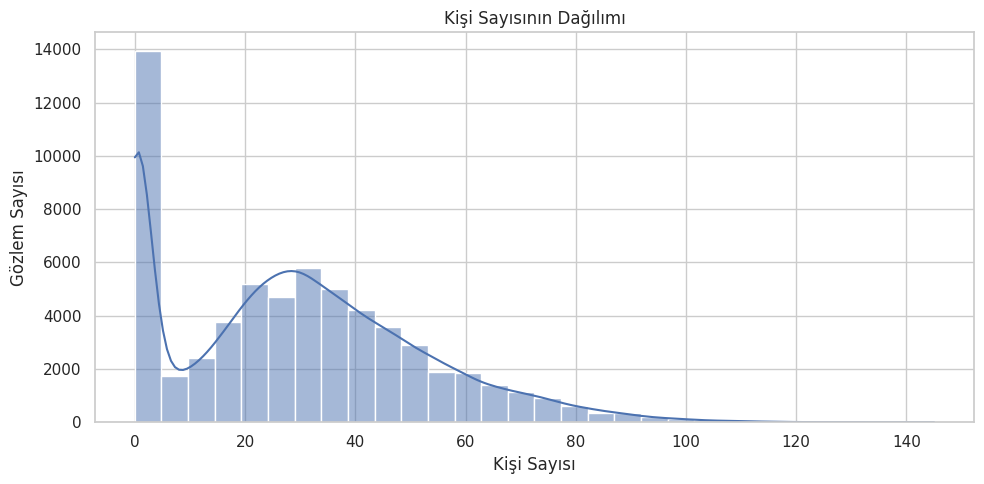

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="number_people",
    bins=30,
    kde=True
)

plt.title("Kişi Sayısının Dağılımı")
plt.xlabel("Kişi Sayısı")
plt.ylabel("Gözlem Sayısı")
plt.tight_layout()
plt.show()

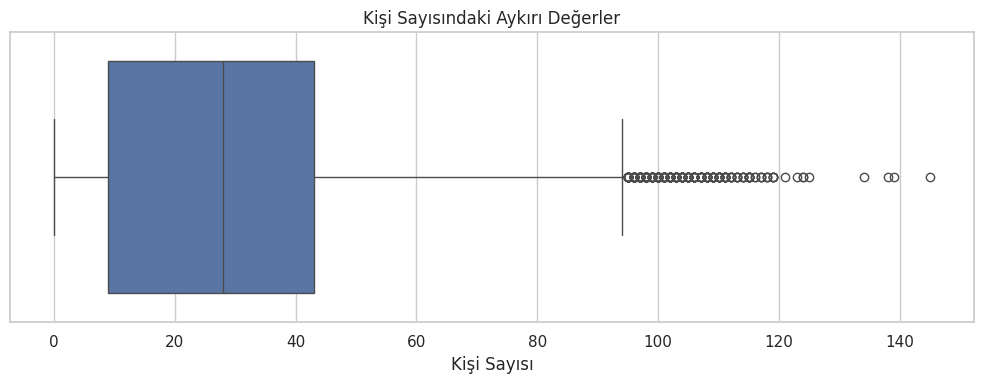

In [12]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="number_people"
)

plt.title("Kişi Sayısındaki Aykırı Değerler")
plt.xlabel("Kişi Sayısı")
plt.tight_layout()
plt.show()

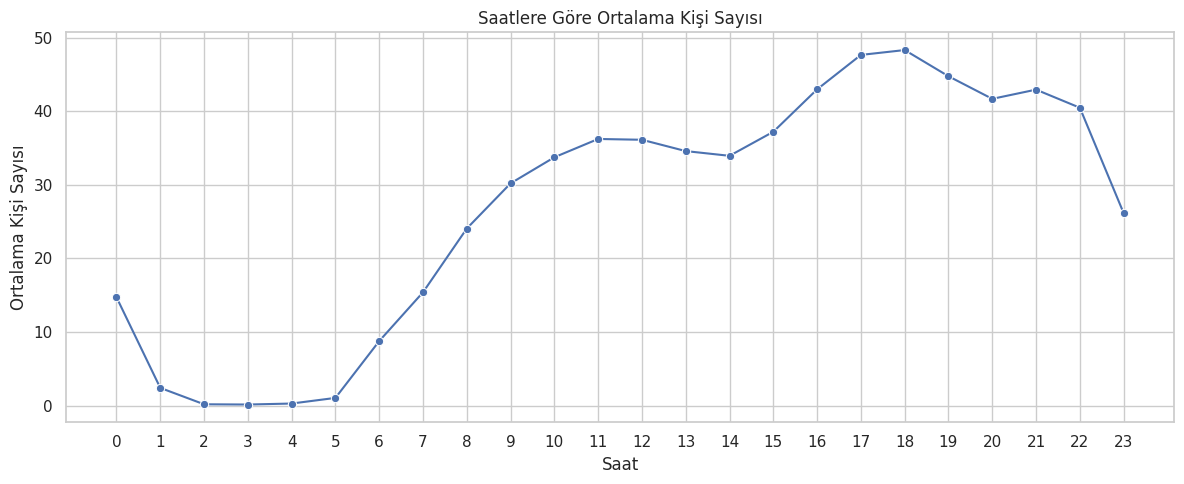

In [13]:
saatlik_ortalama = (
    df.groupby("hour", as_index=False)["number_people"]
    .mean()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=saatlik_ortalama,
    x="hour",
    y="number_people",
    marker="o"
)

plt.title("Saatlere Göre Ortalama Kişi Sayısı")
plt.xlabel("Saat")
plt.ylabel("Ortalama Kişi Sayısı")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

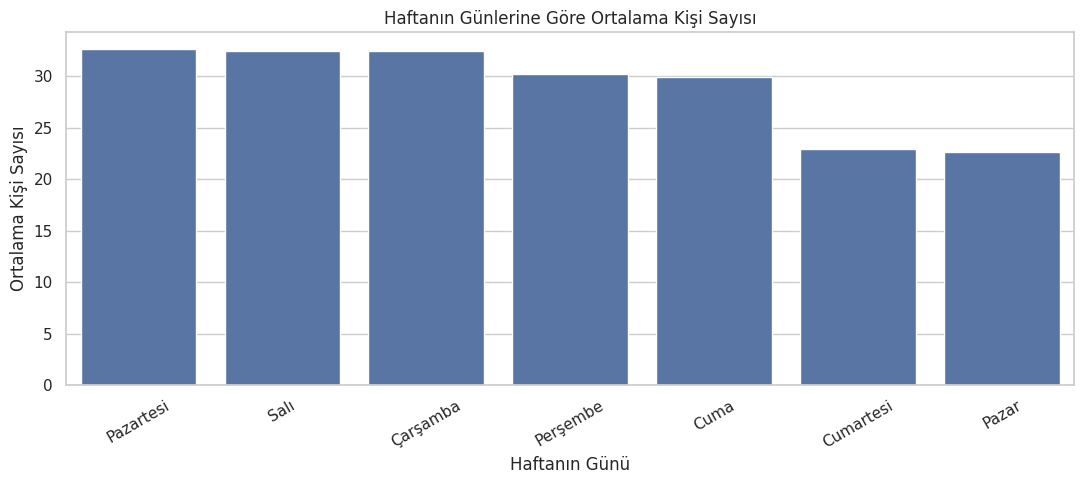

In [14]:
gun_etiketleri = [
    "Pazartesi",
    "Salı",
    "Çarşamba",
    "Perşembe",
    "Cuma",
    "Cumartesi",
    "Pazar"
]

gunluk_ortalama = (
    df.groupby("day_of_week", as_index=False)["number_people"]
    .mean()
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=gunluk_ortalama,
    x="day_of_week",
    y="number_people",
    order=range(7)
)

plt.title("Haftanın Günlerine Göre Ortalama Kişi Sayısı")
plt.xlabel("Haftanın Günü")
plt.ylabel("Ortalama Kişi Sayısı")
plt.xticks(range(7), gun_etiketleri, rotation=30)
plt.tight_layout()
plt.show()

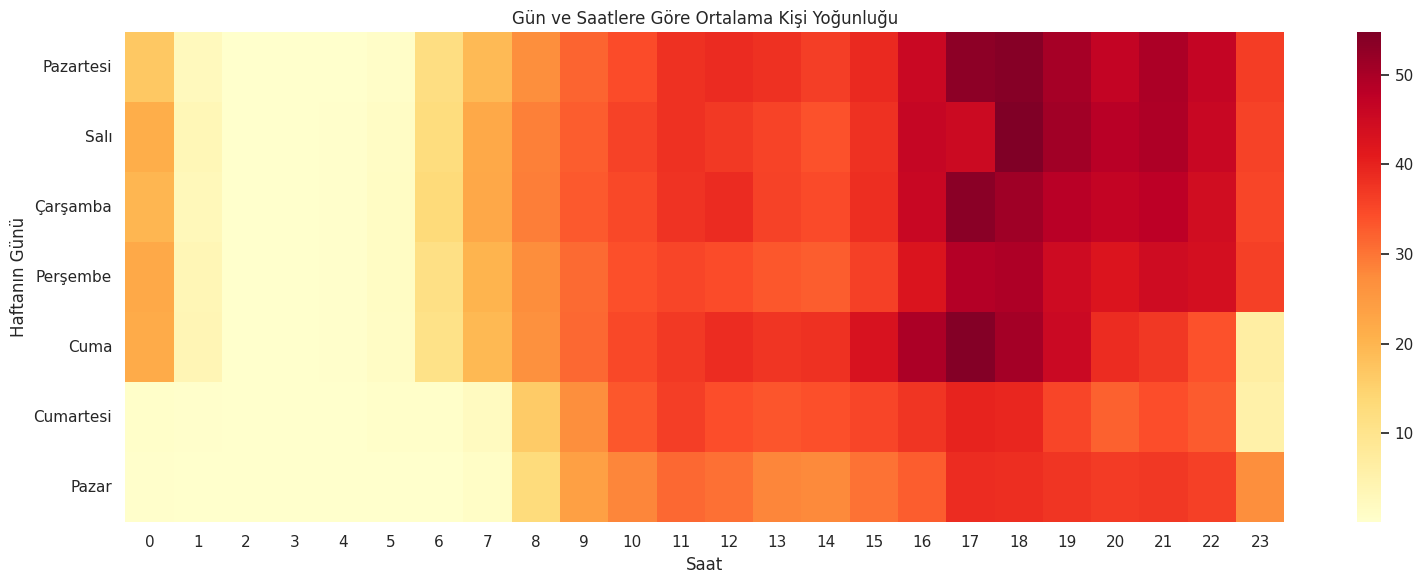

In [15]:
gun_saat_tablosu = df.pivot_table(
    index="day_of_week",
    columns="hour",
    values="number_people",
    aggfunc="mean"
)

gun_saat_tablosu = gun_saat_tablosu.reindex(range(7))
gun_saat_tablosu.index = gun_etiketleri

plt.figure(figsize=(16, 6))

sns.heatmap(
    gun_saat_tablosu,
    cmap="YlOrRd"
)

plt.title("Gün ve Saatlere Göre Ortalama Kişi Yoğunluğu")
plt.xlabel("Saat")
plt.ylabel("Haftanın Günü")
plt.tight_layout()
plt.show()

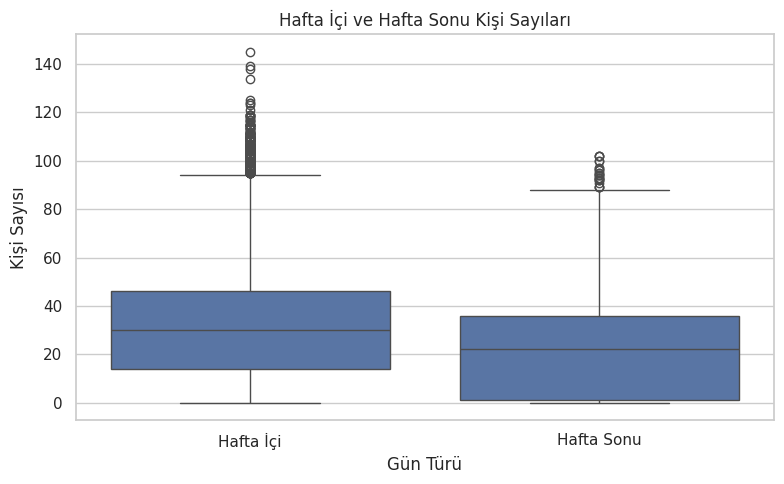

In [16]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df,
    x="is_weekend",
    y="number_people"
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Hafta İçi", "Hafta Sonu"])

plt.title("Hafta İçi ve Hafta Sonu Kişi Sayıları")
plt.xlabel("Gün Türü")
plt.ylabel("Kişi Sayısı")
plt.tight_layout()
plt.show()

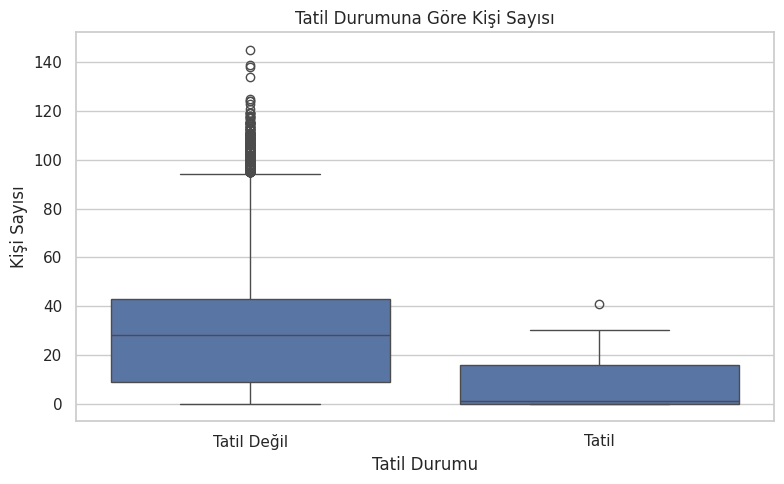

In [17]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df,
    x="is_holiday",
    y="number_people"
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Tatil Değil", "Tatil"])

plt.title("Tatil Durumuna Göre Kişi Sayısı")
plt.xlabel("Tatil Durumu")
plt.ylabel("Kişi Sayısı")
plt.tight_layout()
plt.show()

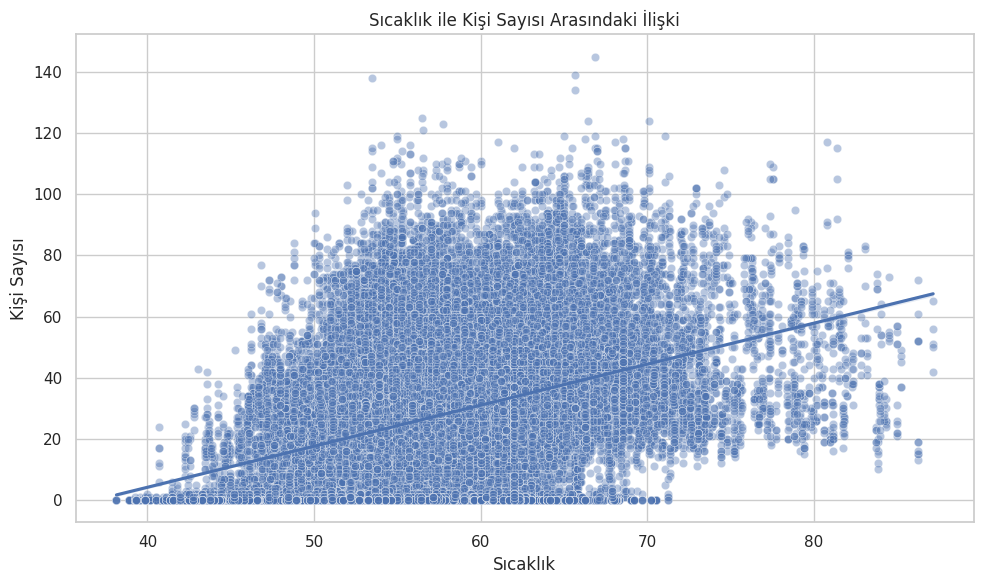

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="temperature",
    y="number_people",
    alpha=0.4
)

sns.regplot(
    data=df,
    x="temperature",
    y="number_people",
    scatter=False
)

plt.title("Sıcaklık ile Kişi Sayısı Arasındaki İlişki")
plt.xlabel("Sıcaklık")
plt.ylabel("Kişi Sayısı")
plt.tight_layout()
plt.show()

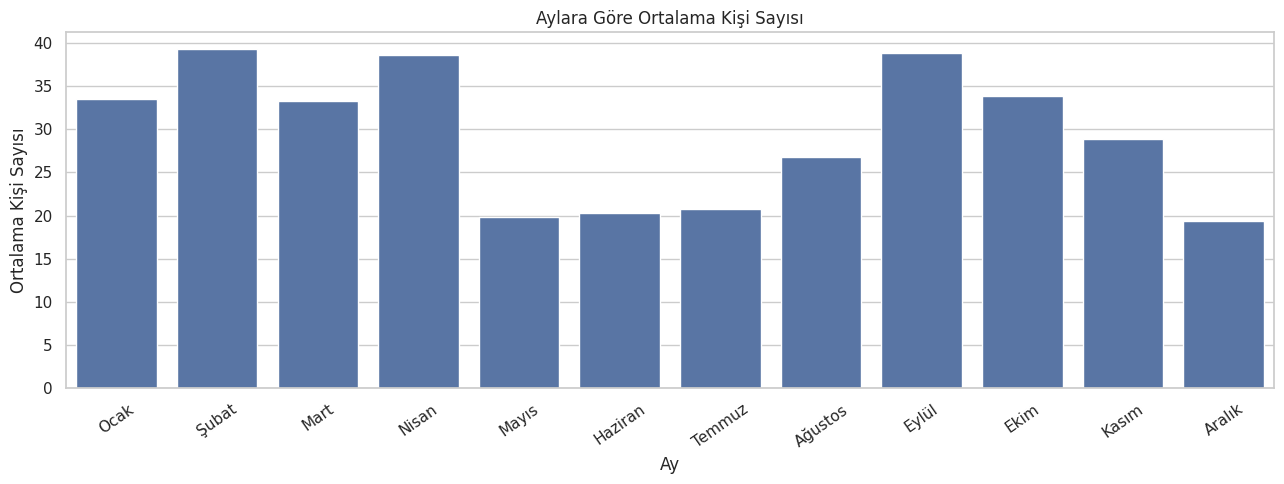

In [19]:
ay_etiketleri = [
    "Ocak",
    "Şubat",
    "Mart",
    "Nisan",
    "Mayıs",
    "Haziran",
    "Temmuz",
    "Ağustos",
    "Eylül",
    "Ekim",
    "Kasım",
    "Aralık"
]

aylik_ortalama = (
    df.groupby("month", as_index=False)["number_people"]
    .mean()
)

plt.figure(figsize=(13, 5))

sns.barplot(
    data=aylik_ortalama,
    x="month",
    y="number_people",
    order=range(1, 13)
)

plt.title("Aylara Göre Ortalama Kişi Sayısı")
plt.xlabel("Ay")
plt.ylabel("Ortalama Kişi Sayısı")
plt.xticks(range(12), ay_etiketleri, rotation=35)
plt.tight_layout()
plt.show()

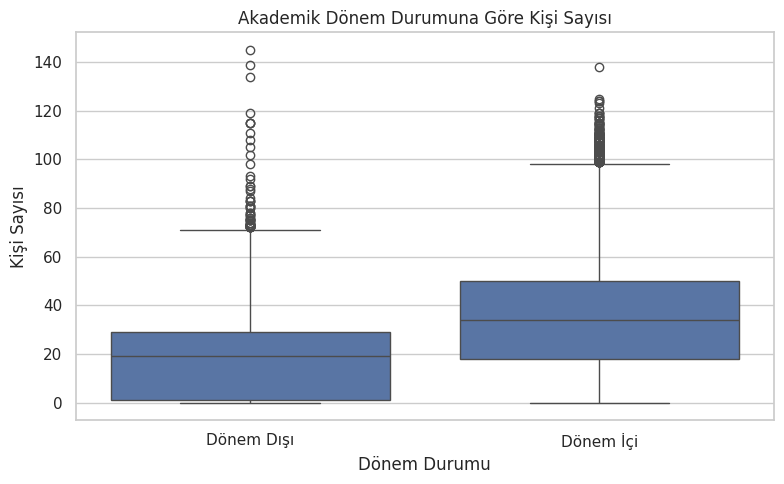

In [20]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df,
    x="is_during_semester",
    y="number_people"
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Dönem Dışı", "Dönem İçi"])

plt.title("Akademik Dönem Durumuna Göre Kişi Sayısı")
plt.xlabel("Dönem Durumu")
plt.ylabel("Kişi Sayısı")
plt.tight_layout()
plt.show()

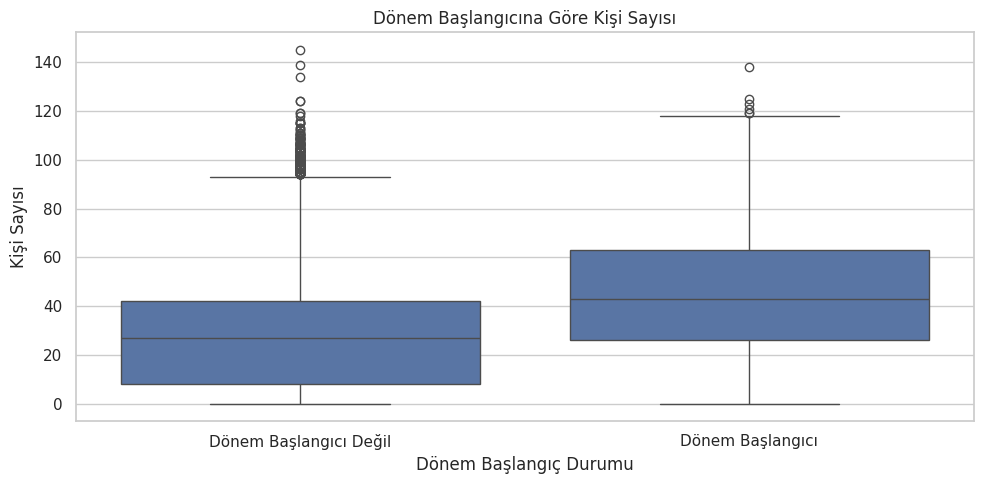

In [21]:
plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    data=df,
    x="is_start_of_semester",
    y="number_people"
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Dönem Başlangıcı Değil", "Dönem Başlangıcı"])

plt.title("Dönem Başlangıcına Göre Kişi Sayısı")
plt.xlabel("Dönem Başlangıç Durumu")
plt.ylabel("Kişi Sayısı")
plt.tight_layout()
plt.show()

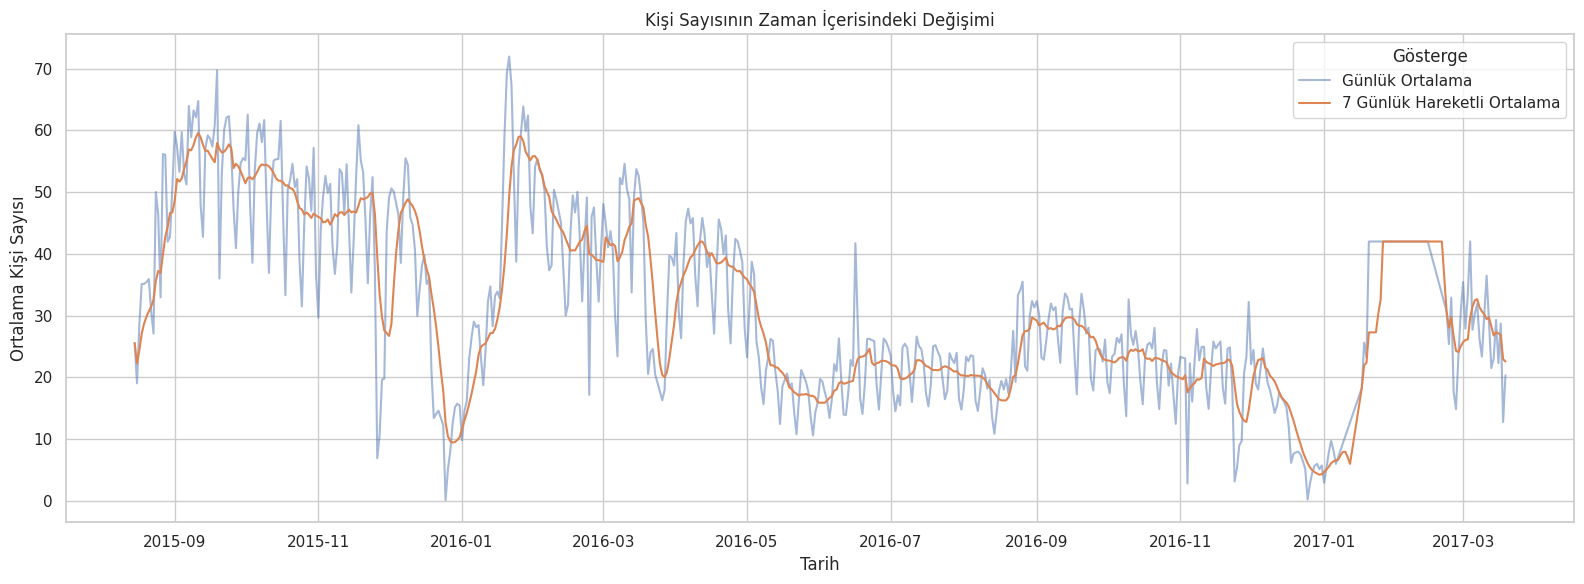

In [23]:
df["date"] = pd.to_datetime(df["date"], utc=True)

gunluk_ortalama = (
    df.set_index("date")["number_people"]
    .resample("D")
    .mean()
    .reset_index()
)

gunluk_ortalama["hareketli_ortalama"] = (
    gunluk_ortalama["number_people"]
    .rolling(window=7, min_periods=1)
    .mean()
)

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=gunluk_ortalama,
    x="date",
    y="number_people",
    alpha=0.5,
    label="Günlük Ortalama"
)

sns.lineplot(
    data=gunluk_ortalama,
    x="date",
    y="hareketli_ortalama",
    label="7 Günlük Hareketli Ortalama"
)

plt.title("Kişi Sayısının Zaman İçerisindeki Değişimi")
plt.xlabel("Tarih")
plt.ylabel("Ortalama Kişi Sayısı")
plt.legend(title="Gösterge")
plt.tight_layout()
plt.show()

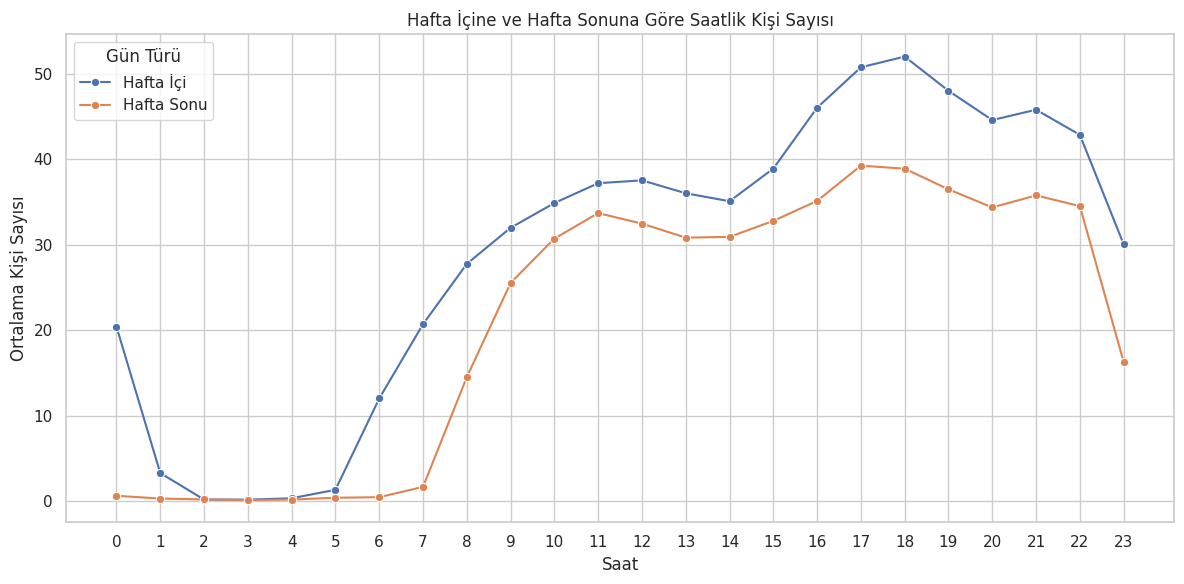

In [24]:
hafta_saat_ortalama = (
    df.groupby(["hour", "is_weekend"], as_index=False)["number_people"]
    .mean()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=hafta_saat_ortalama,
    x="hour",
    y="number_people",
    hue="is_weekend",
    marker="o"
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=["Hafta İçi", "Hafta Sonu"],
    title="Gün Türü"
)

plt.title("Hafta İçine ve Hafta Sonuna Göre Saatlik Kişi Sayısı")
plt.xlabel("Saat")
plt.ylabel("Ortalama Kişi Sayısı")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

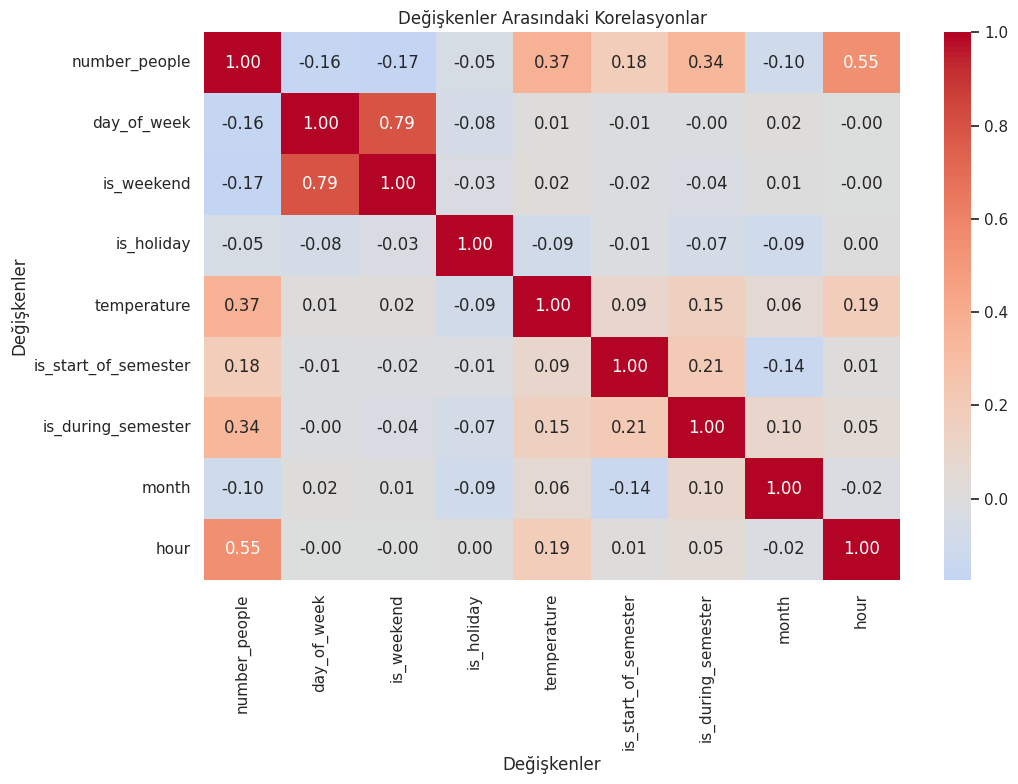

In [25]:
korelasyon_sutunlari = [
    "number_people",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "temperature",
    "is_start_of_semester",
    "is_during_semester",
    "month",
    "hour"
]

korelasyon = df[korelasyon_sutunlari].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    korelasyon,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Değişkenler Arasındaki Korelasyonlar")
plt.xlabel("Değişkenler")
plt.ylabel("Değişkenler")
plt.tight_layout()
plt.show()

In [26]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17


In [27]:
df['year'] = df['date'].dt.year

In [28]:
df.drop('date', axis=1, inplace=True)

In [29]:
df.drop('timestamp', axis = 1, inplace=True)

In [30]:
X = df.drop('number_people', axis=1)
y = df['number_people']

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [32]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [34]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error



In [35]:
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)
y_pred = lin_reg.predict(X_test)
print("r2 score:",r2_score(y_test,y_pred))
print("mse:",mean_squared_error(y_test,y_pred))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred)))



r2 score: 0.5989271376662775
mse: 208.8207913079756
rmse: 14.45063290337055


In [37]:
lasso_reg = Lasso()
lasso_reg.fit(X_train,y_train)
y_pred = lasso_reg.predict(X_test)
print("r2 score:",r2_score(y_test,y_pred))
print("mse:",mean_squared_error(y_test,y_pred))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred)))

r2 score: 0.5847671974050243
mse: 216.19324207171786
rmse: 14.703511215751082


In [38]:
ridge_reg = Ridge()
ridge_reg.fit(X_train,y_train)
y_pred = ridge_reg.predict(X_test)
print("r2 score:",r2_score(y_test,y_pred))
print("mse:",mean_squared_error(y_test,y_pred))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred)))

r2 score: 0.5989271139851151
mse: 208.82080363770297
rmse: 14.450633329986024


In [39]:
dec_tree_reg = DecisionTreeRegressor()
dec_tree_reg.fit(X_train,y_train)
y_pred = dec_tree_reg.predict(X_test)
print("r2 score:",r2_score(y_test,y_pred))
print("mse:",mean_squared_error(y_test,y_pred))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred)))

r2 score: 0.9168915485308583
mse: 43.270872277881
rmse: 6.578059917474224


In [40]:
rft = RandomForestRegressor()
rft.fit(X_train,y_train)
y_pred = rft.predict(X_test)
print("r2 score:",r2_score(y_test,y_pred))
print("mse:",mean_squared_error(y_test,y_pred))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred)))

r2 score: 0.9202532346796085
mse: 41.52059189833496
rmse: 6.443647406425569


In [41]:
knnr = KNeighborsRegressor()
knnr.fit(X_train,y_train)
y_pred = knnr.predict(X_test)
print("r2 score:",r2_score(y_test,y_pred))
print("mse:",mean_squared_error(y_test,y_pred))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred)))

r2 score: 0.9015823652338519
mse: 51.241682747973755
rmse: 7.158329605988659


In [42]:
params = {
    "n_estimators": [150, 250, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7, 1.0],
    "bootstrap": [True],
    "max_samples": [None, 0.8]
}

In [43]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=params,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)
y_pred = random_search.predict(X_test)
print("r2 score:",r2_score(y_test,y_pred))
print("mse:",mean_squared_error(y_test,y_pred))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred)))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
r2 score: 0.9211958325896495
mse: 41.02982311304569
rmse: 6.4054526079774945


In [45]:
random_search.best_params_

{'n_estimators': 150,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_samples': 0.8,
 'max_features': 0.7,
 'max_depth': None,
 'bootstrap': True}